### **Introduction**
This data analysis utilizes a dataset containing life expectancy and GDP data for five countries over multiple years. By examining both temporal and cross-country variations, the study seeks to uncover patterns that illustrate how improvements in economic growth may correspond to changes in population health outcomes.

#### **Project Scope**

- Investigates the relationship between life expectancy and economic performance (GDP) across five countries over multiple years.  
- Analyzes data patterns to understand how economic growth influences population health outcomes.  
- Summarizes and visualizes key statistics using tables**, line plots, bar charts, and box plots to highlight variations and trends across time and countries.  
- Explores relationships between GDP and life expectancy through scatter plots, trend analysis, and correlation measures.  
- Applies statistical methods to evaluate the significance and strength of observed relationships between economic and health indicators.  
- Builds predictive models (e.g., regression) to estimate life expectancy based on GDP and time, assessing accuracy and reliability.  
- Combines data visualization, statistical analysis, and predictive modeling to deliver insights on the socioeconomic factors shaping global health and longevity.  


#### Data Overview
The dataset consists of 96 observations and four key attributes representing annual life expectancy and GDP data for five countries. It combines both cross-sectional and time-series characteristics, enabling comparative and trend-based analyses. 

Results:

The dataset comprises one categorical variable and three numeric variables:
- Categorical variable: Country
- Numeric variable: Year, Life expectancy at birth (years), GDP

The categorical data, Country consist of:

1. Chile
2. China
3. Germany
4. Mexico
5. United States of America
6. Zimbabwe

Loading the CSV dataset and checking the data types containing life expectancy, years and GDP.

In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix
import plotly.express as px
from pathlib import Path
import seaborn as sns

life_data = pd.read_csv('all_data.csv')
life_data.info()
life_data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 4 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Country                           96 non-null     object 
 1   Year                              96 non-null     int64  
 2   Life expectancy at birth (years)  96 non-null     float64
 3   GDP                               96 non-null     float64
dtypes: float64(2), int64(1), object(1)
memory usage: 3.1+ KB


,Country,Year,Life expectancy at birth (years),GDP
0,Chile,2000,77.3,7.786093e+10
1,Chile,2001,77.3,7.097992e+10
2,Chile,2002,77.8,6.973681e+10
3,Chile,2003,77.9,7.564346e+10
4,Chile,2004,78.0,9.921039e+10


Data cleaning:
- Rename 'Life expectancy at birth (years)' to 'Life_expectancy_years'
- Update the country name from 'United States of America' to 'USA'.
- Convert GDP by dividing the column value by 1e9
- A new column 'GDP_in_billion' is created to handle large values of GDP

In [80]:
life_data.rename(columns={'Life expectancy at birth (years)': 'Life_expectancy_years'}, inplace=True)
life_data['Country'].replace({'United States of America': 'USA'}, inplace=True)
life_data['GDP_in_trillion'] = life_data['GDP'] / 1e12
# life_data.drop(columns=['GDP'], inplace=True)

/var/folders/3w/7_wgs56n3c30fpsrg0g2mg_00000gn/T/ipykernel_25508/2964992889.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  life_data['Country'].replace({'United States of America': 'USA'}, inplace=True)


#### Summary statistics
This stage focuses on identifying central tendencies, dispersion, and overall trends to build an initial understanding of the data before deeper exploration and modeling.
These statistics provide insight into the range and variability of life expectancy and GDP across all observations. 
- The mean and standard deviation help establish the central tendency and spread of each variable, 
- Minimum and Maximum values indicate the observed extremes across the dataset.
- Average of Life expectancy and GDP across the five selected countries


The describe function is used to get a summary of the numeric variables GDP and Life expectancy at birth (years).

In [81]:
life_data.describe()[['Life_expectancy_years', 'GDP_in_trillion']]

,Life_expectancy_years,GDP_in_trillion
count,96.000000,96.000000
mean,72.789583,3.880499
std,10.672882,5.197561
min,44.300000,0.004416
25%,74.475000,0.173302
50%,76.750000,1.280220
75%,78.900000,4.067510
max,81.000000,18.100000


Frequency per Country

The value count verifies the frequency of each country in the dataset and shows that the observations are evenly distributed across all countries.

In [ ]:
life_data['Country'].value_counts()

##### Compare GDP Vs Life Expectancy groupings
The 'groupby' function highlights the average life expectancy and GDP for each country, offering a quick comparison of relative economic performance and health outcomes.
- Germany has the highest average life expectancy with Zimbabwe recording the lowest average over time.
- USA has the highest average GDP of 14.8 trillion dollars over time with Zimbabwe having the lowest 0.01 trillion dollars.

In [83]:
life_data.groupby('Country')[['Life_expectancy_years', 'GDP_in_trillion']].mean().round(2)

,Life_expectancy_years,GDP_in_trillion
Country,,
Chile,78.94,0.17
China,74.26,4.96
Germany,79.66,3.09
Mexico,75.72,0.98
USA,78.06,14.08
Zimbabwe,50.09,0.01


Mininum and Maximum of GDP and Life expectancy per country between 2000 and 2015

In [ ]:
print("==== Life Expectancy per country ====")
for country in life_data['Country'].unique():
    country_data = life_data[life_data['Country'] == country]
    print(f"{country}: ", (int(country_data['Life_expectancy_years'].min()), int(country_data['Life_expectancy_years'].max())))

print("==== GDP per country ====")
for country in life_data['Country'].unique():
    country_data = life_data[life_data['Country'] == country]
    print(f"{country}: ", (float(round(country_data['GDP_in_trillion'].min(), 4)), float(round(country_data['GDP_in_trillion'].max(), 4))))       

The data visualization in Fig. 1 illustrates the distribution of life expectancy across countries, highlighting both the median and the variability.
Meanwhile, the boxplot in Fig. 2 uses a logarithmic scale to compare GDP levels across countries with different economic sizes more effectively. This approach helps to explore whether higher GDPs are associated with higher or more stable life expectancy values.

Results:
- Countries like Chile, China, Germany, and the USA show narrow boxes, indicating low variation in life expectancy over time. This suggests that life expectancy remained relatively stable in these countries, with overall high values.
- Conversely, a wider box for Zimbabwe indicates greater fluctuations in life expectancy, reflecting improvements over time. Although Zimbabwe's life expectancy remains the lowest among the countries analyzed, ranging between 44 and 60 years, it recorded improvement which could be clearly seen through the time series plot 'lineplot'.
- Germany, Mexico, and the USA exhibit very low variation in GDP over the years, with no extreme spikes among higher-income observations.
- China shows a steady increase in GDP, with moderate variation over time.
- Zimbabwe has the lowest GDP, with a small difference between the median and the 25th percentile.
- Overall, countries with relatively high GDPs, such as the USA, Germany, Mexico, and China, tend to have correspondingly higher life expectancy.



Side by side boxplot (Life expectancy Vs GDP)

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
plt.subplot(1,2,1)
sns.boxplot(data=life_data, x='Country', y='Life_expectancy_years', palette='Set2', showmeans=True)
plt.title('Figure 1: Distribution of Life Expectancy by Country')
plt.xlabel('Country')
plt.ylabel('Life Expectancy (years)')

plt.subplot(1,2,2)
sns.boxplot(data=life_data, x='Country', y='GDP', palette='Set3')
plt.title('Figure 2: Distribution of GDP by Country')
plt.xlabel('Country')
plt.ylabel('GDP (USD)')
plt.yscale('log')  # Log scale for better visualization

plt.show()

Check the year interval

In [86]:
print(sorted(life_data.Year.unique().tolist()) )

[2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015]


##### Time Series (GDP vs Life Expectancy)

The next visualization checks the trend between Life expectancy and GDP between year 2000 and 2015. The line plot gives us more insight and understanding into changes that occured over time in GDP and Life expectancy.

Results:
- There was a steady drop in life expectancy for Zimbabwe between 2000 and 2004 but observed upward trajectory between 2004 and 2015
- Other countries like USA, China, Chile, Mexico and Germany observed slight rise and drop in both Life expectancy and GDP
- Zimbabwe observed a drop in GDP between 2000 and 2008 and picked up between 2008 and 2015

Side by side Lineplot:

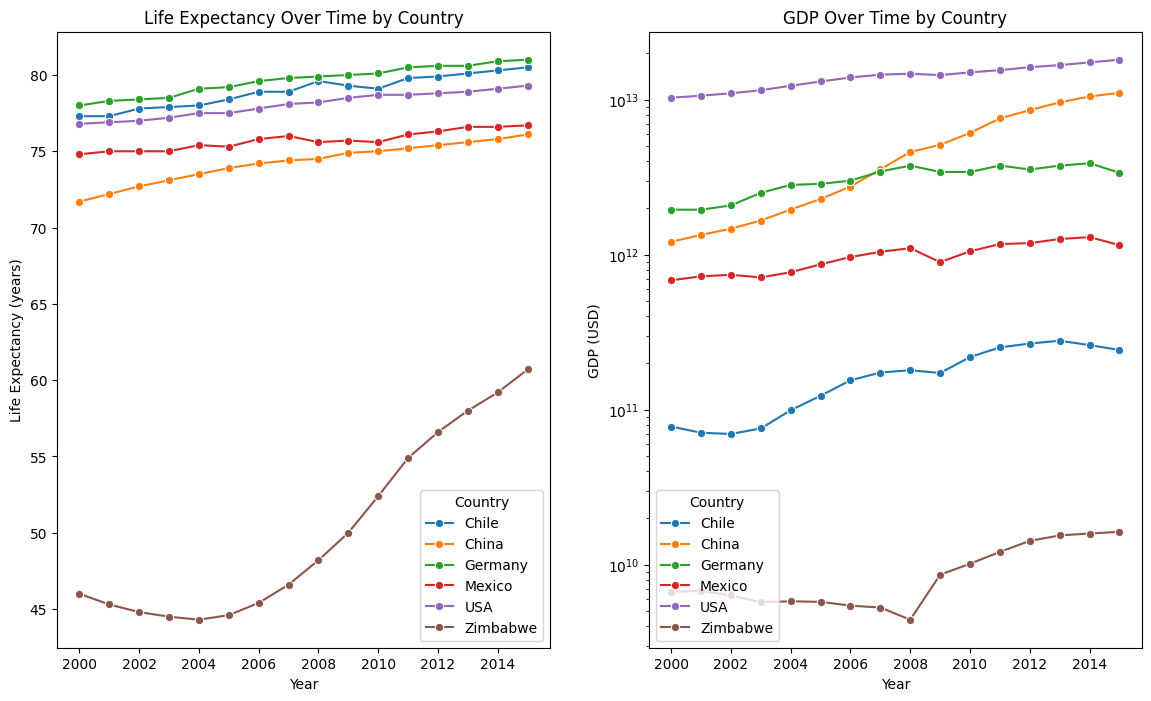

In [87]:
plt.figure(figsize=(14,8))
ax1 = plt.subplot(1,2,1)
sns.lineplot(data=life_data, x='Year', y='Life_expectancy_years', hue='Country', marker='o')
plt.title('Life Expectancy Over Time by Country')
plt.xlabel('Year')
plt.ylabel('Life Expectancy (years)')
plt.legend(title='Country')

plt.subplot(1,2,2)
sns.lineplot(data=life_data, x='Year', y='GDP', hue='Country', marker='o')
plt.title('GDP Over Time by Country')
plt.xlabel('Year')
plt.ylabel('GDP (USD)')
plt.yscale('log')
plt.legend(title='Country')

plt.show()




##### GDP Vs Life Expectancy average per country trends

Here, the data is organized with countries as the index and years as the columns, while GDP and life expectancy serve as the summarized values by using a pivot table. The objective is to:

- Get the average of GDP and Life expectancy per country, line them up in a Lineplot and observe the trends.
- Compare the data of the country-level plot with and without the average of GDP and Life expectancy.
- A Lineplot is used to visualize the trends between GDP and Life Expectancy over the period of 15 years.

Pivotting the dataset:

In [94]:
df_pivot = life_data.pivot_table(
    index='Country', 
    columns='Year', 
    values=['GDP', 'Life_expectancy_years'], 
    aggfunc='mean'
)
df_pivot.head()

GDP                                                          \
Year             2000          2001          2002          2003          2004   
Country                                                                         
Chile    7.786093e+10  7.097992e+10  6.973681e+10  7.564346e+10  9.921039e+10   
China    1.211350e+12  1.339400e+12  1.470550e+12  1.660290e+12  1.955350e+12   
Germany  1.949950e+12  1.950650e+12  2.079140e+12  2.505730e+12  2.819250e+12   
Mexico   6.836480e+11  7.247040e+11  7.415600e+11  7.132840e+11  7.702680e+11   
USA      1.030000e+13  1.060000e+13  1.100000e+13  1.150000e+13  1.230000e+13   

                                                                               \
Year             2005          2006          2007          2008          2009   
Country                                                                         
Chile    1.229650e+11  1.547880e+11  1.736060e+11  1.796380e+11  1.723890e+11   
China    2.285970e+12  2.752130e+12  3.552180e+12  4.598210e+12  5.109950e+12   
Germany  2.861410e+12  3.002450e+12  3.439950e+12  3.752370e+12  3.418010e+12   
Mexico   8.663460e+11  9.652810e+11  1.043470e+12  1.101280e+12  8.949490e+11   
USA      1.310000e+13  1.390000e+13  1.450000e+13  1.470000e+13  1.440000e+13   

         ... Life_expectancy_years                                            \
Year     ...                  2006  2007  2008  2009  2010  2011  2012  2013   
Country  ...                                                                   
Chile    ...                  78.9  78.9  79.6  79.3  79.1  79.8  79.9  80.1   
China    ...                  74.2  74.4  74.5  74.9  75.0  75.2  75.4  75.6   
Germany  ...                  79.6  79.8  79.9  80.0  80.1  80.5  80.6  80.6   
Mexico   ...                  75.8  76.0  75.6  75.7  75.6  76.1  76.3  76.6   
USA      ...                  77.8  78.1  78.2  78.5  78.7  78.7  78.8  78.9   

                     
Year     2014  2015  
Country              
Chile    80.3  80.5  
China    75.8  76.1  
Germany  80.9  81.0  
Mexico   76.6  76.7  
USA      79.1  79.3  

[5 rows x 32 columns]

Next step is to apply the stack function to move the 'Year' column level into the row index, transforming the dataset wide-format into a long-format data structure. Specifically, we will:

- Stack the data at level 1 (the second-level column index corresponding to 'Year') to pivot it into the row index
- Rename the resulting columns (GDP and Life_expectancy) to indicate that they represent average values
- Reset the index to finalize the long-format structure

Stacking the dataset:


In [ ]:
df_pivot = df_pivot.stack(level=1).rename(
    columns={'GDP': 'Avg_GDP', 'Life_expectancy_years': 'Avg_Life_expectancy'}
).reset_index()

df_pivot.head()

Plotting average GDP & Life expectancy per year (Time Series):

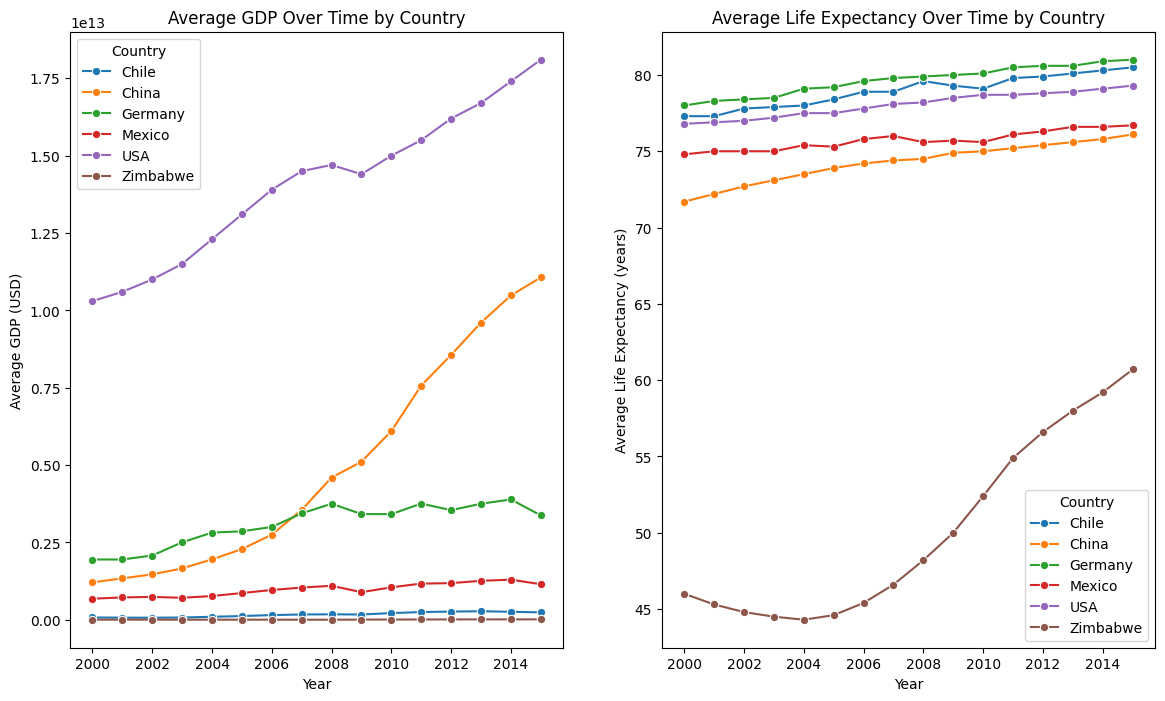

In [93]:
plt.figure(figsize=(14,8))
plt.subplot(1,2,1)
sns.lineplot(data=df_pivot, x='Year', y='Avg_GDP', hue='Country', marker='o')
plt.title('Average GDP Over Time by Country')
plt.xscale
plt.xlabel('Year')
plt.ylabel('Average GDP (USD)')
plt.legend(title='Country') 

plt.subplot(1,2,2)
sns.lineplot(data=df_pivot, x='Year', y='Avg_Life_expectancy', hue='Country', marker='o')
plt.title('Average Life Expectancy Over Time by Country')
plt.xlabel('Year')
plt.ylabel('Average Life Expectancy (years)')
plt.legend(title='Country')
plt.show()

##### Summary of Key Descriptive Insights
- The time-series line plot of the average GDPs per country appears to diverge from the original country-level plots in several places, indicating that there may be anomalies or outliers affecting the averaged values. However, this discrepancy in the data needs to be proved.
- The line plot of the average life expectancy closely follows the individual country-level trends, suggesting that there are no noticeable anomalies in the life expectancy data.

Note: The deviations will be studied in the Exploration Data Analysis section of this project.

#### Exploratory Data Analysis (EDA)
Exploratory Data Analysis aims to uncover underlying patterns, relationships, and anomalies within the dataset. In this stage, we go beyond summary statistics to visually and quantitatively examine how economic performance (GDP) and life expectancy interact across different countries and time periods.

The objectives of this analysis are to:
- Explore the relationship between life expectancy and GDP.
- Identify correlation strength and direction between the two variables.
- Detect potential outliers or deviations from general trends.
- Visualize cross-country and temporal variations.

Interpretation:

A positive correlation suggests that as GDP increases, life expectancy also tends to rise. The strength of this correlation indicates how closely linked economic prosperity and life expectancy outcomes are across the observed countries and years.

Results:
- The correlation value of individual country shows a very strong positive correlation indicating linearity
- This plot illustrates how life expectancy changes with increasing GDP

Note: Earlier, we calculated an overall correlation of 0.343 across all countries, which is weaker than the correlations observed at the individual country level.

Correlation Between GDP and Life Expectancy:

In [ ]:
# Compute the Pearson correlation coefficient
corr_value = life_data['Life_expectancy_years'].corr(life_data['GDP'])
print(f"Correlation between GDP and Life Expectancy: {corr_value:.3f}")

##### Relationship between GDP and Life expectancy per Country
This analysis illustrates the correlation/relationship between GDP and life expectancy for each country compared to the overall correlation across all countries.

Interpretation:

- The table below shows how the relationship between GDP and life expectancy varies across countries. A stronger correlation for certain countries might reflect consistent socioeconomic improvements, whereas weaker correlations may indicate additional factors influencing life expectancy.
- This scatter plot illustrates how life expectancy changes with increasing GDP. 

Results:
- The observed correlation values indicate that there is a strong positive correlation between each country's GDP and Life expectancy.
- USA has the highest correlation value of 0.982 while Mexico has the lowest with the value of 0.932
- In the scatter plot, countries clustering along an upward trajectory indicate a strong positive association.
- Zimbabwe’s GDP shows a slight initial decline over the period, followed by a sharp recovery, although overall changes remain relatively small.

In [ ]:
country_corr = life_data.groupby('Country')[['GDP', 'Life_expectancy_years']].corr().unstack().iloc[:,1].round(3)
country_corr

Scatter Plot (GDP vs. Life Expectancy) per country : 

In [ ]:
plt.figure(figsize=(12,8))
sns.scatterplot(data=life_data, x='GDP', y='Life_expectancy_years', hue='Country', palette='Dark2', s=70)
plt.xscale('log')  # Log scale for GDP to manage large range differences
plt.title('Relationship Between GDP and Life Expectancy')
plt.xlabel('GDP (log scale, USD)')
plt.ylabel('Life Expectancy (years)')
plt.legend(title='Country')
plt.show()

#### Outlier detection
Firstly, we check if there are outliers in GDP and Life expectancy per country in the dataset. Previous data analysis of the average GDP and Life expectancy suggested that there might be the presence of outliers clearly shown in the lineplot.
Here, we do the following to check the presence of outliers:

- Check the lower and upper bound of the GDP and Life expectancy per country
- Filter the dataset for the lower and upper bound
- Validate the dataset if there was outlier or not in GDP and life expectancy per country


The analysis indicates that no outliers were detected in the GDP or life expectancy data for any country. The minor deviations observed in the earlier line plot are likely attributable to small gaps in the recorded GDP and life expectancy values. These gaps may account for the observed differences between the datasets with and without averaging.

In [124]:
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = data[(data[column] < lower) | (data[column] > upper)]
    
    # If no outliers, set explicitly to "No Outliers"
    if outliers.empty:
        outliers_result = "No Outliers"
    else:
        outliers_result = outliers

    return outliers_result, lower, upper

# Dictionary to store results
outlier_results = {}

# Loop per country
for country, group in life_data.groupby("Country"):

    country_stats = {}

    for col in ['GDP', 'Life_expectancy_years']:
        outliers, lower, upper = detect_outliers_iqr(group, col)

        country_stats[col] = {
            "Number of Outliers": 0 if outliers == "No Outliers" else len(outliers),
            "Lower Bound": round(lower, 2),
            "Upper Bound": round(upper, 2),
            "Outlier Rows": outliers
        }

    outlier_results[country] = country_stats

# Convert to a readable summary DataFrame
summary_rows = []
for country, stats in outlier_results.items():
    for col, result in stats.items():
        summary_rows.append({
            "Country": country,
            "Column": col,
            "Number of Outliers": result["Number of Outliers"],
            "Lower Bound": result["Lower Bound"],
            "Upper Bound": result["Upper Bound"]
        })

summary_df = pd.DataFrame(summary_rows)
summary_df

,Country,Column,Number of Outliers,Lower Bound,Upper Bound
0,Chile,GDP,0,-1.327447e+11,4.715692e+11
1,Chile,Life_expectancy_years,0,7.520000e+01,8.260000e+01
2,China,GDP,0,-7.025362e+12,1.672650e+13
3,China,Life_expectancy_years,0,7.063000e+01,7.802000e+01
4,Germany,GDP,0,1.458059e+12,4.878889e+12
5,Germany,Life_expectancy_years,0,7.659000e+01,8.289000e+01
6,Mexico,GDP,0,1.722388e+11,1.747845e+12
7,Mexico,Life_expectancy_years,0,7.384000e+01,7.754000e+01
8,USA,GDP,0,6.737500e+12,2.103750e+13
9,USA,Life_expectancy_years,0,7.547000e+01,8.067000e+01
